# Clustering jerarquico

Objetivo: aplicar clustering aglomerativo y divisivo, visualizar dendrogramas y comparar contra las clases reales.

## 1) Librerias

In [11]:
!pip install pandas matplotlib seaborn scikit-learn scipy

In [12]:
# Datos
import pandas as pd


In [13]:
# Calculo numerico
import numpy as np


In [14]:
# Graficos
import matplotlib.pyplot as plt


In [15]:
# Graficos estadisticos
import seaborn as sns


In [16]:
# Escalamiento
from sklearn.preprocessing import StandardScaler


In [17]:
# Clustering aglomerativo
from sklearn.cluster import AgglomerativeClustering


In [18]:
# Distancias y dendrograma
from scipy.spatial.distance import pdist


In [19]:
# Distancias y dendrograma
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


In [20]:
# Estilo
sns.set_theme(style="whitegrid")


## 2) Cargar y preparar datos

In [21]:
# Cargar archivo
iris_data = pd.read_csv("iris.csv")


In [22]:
# Convertir etiqueta
iris_data["variety"] = iris_data["variety"].astype("category")


In [23]:
# Variables numericas
iris_numerico = iris_data.select_dtypes(include=["number"])


In [24]:
# Estandarizar
scaler = StandardScaler()
iris_normalizado = scaler.fit_transform(iris_numerico)


## 3) Parametros del analisis

In [25]:
# Distancia principal
distancia = "euclidean"


In [26]:
# Linkage principal
linkage_name = "complete"


In [27]:
# Numero de clusters
k = 3


## 4) Clustering aglomerativo

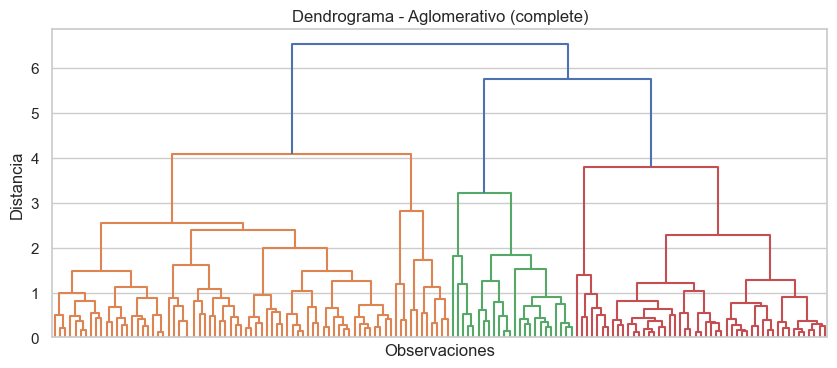

In [28]:
# Matriz de linkage para dendrograma
dist_matrix = pdist(iris_normalizado, metric=distancia)
Z = linkage(dist_matrix, method=linkage_name)
plt.figure(figsize=(10, 4))
dendrogram(Z, color_threshold=None, no_labels=True)
plt.title(f"Dendrograma - Aglomerativo ({linkage_name})")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()


In [29]:
# Cortar dendrograma en k clusters
clusters_agg = fcluster(Z, t=k, criterion="maxclust")


## 5) Clustering divisivo (aproximacion didactica)

In [30]:
# Aproximacion divisiva simple con kmeans para comparar visualmente
from sklearn.cluster import KMeans
modelo_div = KMeans(n_clusters=k, random_state=42, n_init=25)
clusters_div = modelo_div.fit_predict(iris_normalizado) + 1


## 6) Visualizar clusters

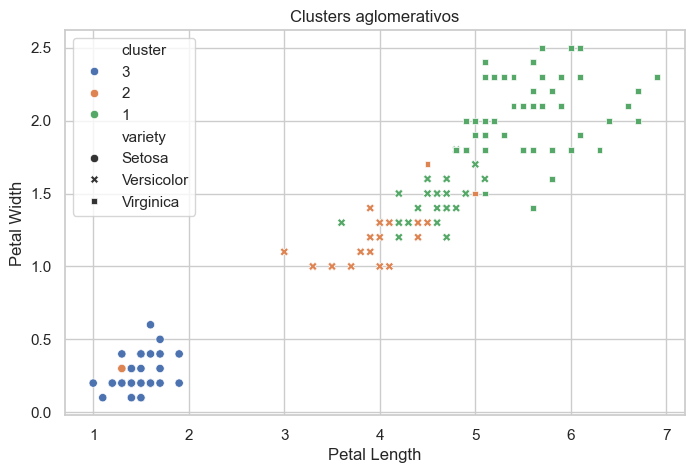

In [31]:
# Plot 2D para aglomerativo
plot_data = iris_numerico.copy()
plot_data["cluster"] = clusters_agg.astype(str)
plot_data["variety"] = iris_data["variety"].astype(str)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_data, x="petal.length", y="petal.width", hue="cluster", style="variety")
plt.title("Clusters aglomerativos")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()


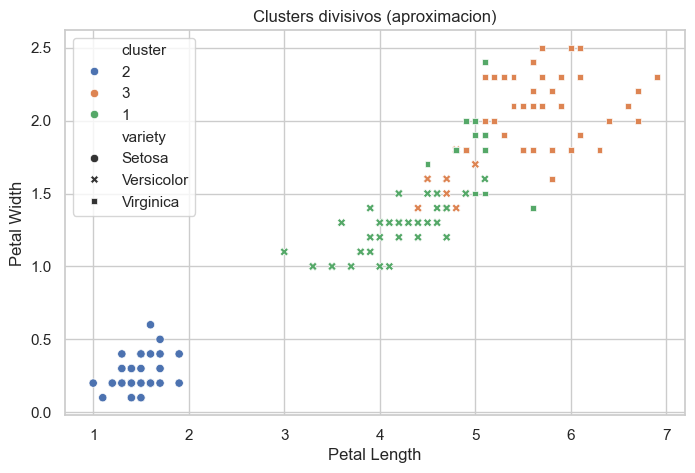

In [32]:
# Plot 2D para divisivo
plot_data_div = iris_numerico.copy()
plot_data_div["cluster"] = clusters_div.astype(str)
plot_data_div["variety"] = iris_data["variety"].astype(str)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_data_div, x="petal.length", y="petal.width", hue="cluster", style="variety")
plt.title("Clusters divisivos (aproximacion)")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()


## 7) Comparacion con clases reales

In [33]:
# Tabla aglomerativo vs variedad
tabla_agg = pd.crosstab(pd.Series(clusters_agg, name="cluster"), iris_data["variety"])
tabla_agg.index = [f"Cluster_{x}" for x in tabla_agg.index]
tabla_agg.columns = [f"Variety_{x}" for x in tabla_agg.columns]
tabla_agg


,Variety_Setosa,Variety_Versicolor,Variety_Virginica
Cluster_1,0,29,48
Cluster_2,1,21,2
Cluster_3,49,0,0


In [34]:
# Tabla divisivo vs variedad
tabla_div = pd.crosstab(pd.Series(clusters_div, name="cluster"), iris_data["variety"])
tabla_div.index = [f"Cluster_{x}" for x in tabla_div.index]
tabla_div.columns = [f"Variety_{x}" for x in tabla_div.columns]
tabla_div


,Variety_Setosa,Variety_Versicolor,Variety_Virginica
Cluster_1,0,39,14
Cluster_2,50,0,0
Cluster_3,0,11,36
